In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import joblib

print("--- Chargement des données ---")
df = pd.read_csv("/content/IRVE_clean_IA.csv")
# 1. Sélection des variables explicatives (Features) adaptées à vos colonnes
# Variables textuelles / catégorielles
features_categoriels = [
    'nom_operateur', 'nom_enseigne', 'implantation_station',
    'accessibilite_pmr', 'condition_acces', 'gratuit'
]

# Variables de types de prises (souvent stockées en True/False ou 0/1)
features_prises = [
    'prise_type_ef', 'prise_type_2', 'prise_type_combo_ccs',
    'prise_type_chademo', 'prise_type_autre'
]

# Variables numériques (Géolocalisation)
features_numeriques = ['consolidated_longitude', 'consolidated_latitude', 'nbre_pdc']

# Cible à prédire
cible = 'puissance_nominale'

# Regroupement de toutes nos features
toutes_features = features_categoriels + features_prises + features_numeriques

# 2. Nettoyage des lignes avec des valeurs manquantes critiques
df_clean = df.dropna(subset=toutes_features + [cible]).copy()

# Conversion explicite des colonnes de prises en chaînes de caractères/catégories si elles sont booléennes
for col in features_prises:
    df_clean[col] = df_clean[col].astype(str)

X = df_clean[toutes_features]
y = df_clean[cible]

print(f"Taille du dataset après nettoyage : {X.shape[0]} lignes et {X.shape[1]} variables explicatives.")

# 3. Séparation : 80% Entraînement / 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Création du Préprocesseur (Pipeline d'encodage)
# On applique le OneHotEncoder sur les variables textuelles ET sur les types de prises
preprocesseur = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_categoriels + features_prises),
        ('num', StandardScaler(), features_numeriques)
    ]
)

# 5. Entraînement du préprocesseur et transformation des données
print("\n--- Prétraitement et Encodage des données ---")
X_train_encoded = preprocesseur.fit_transform(X_train)
X_test_encoded = preprocesseur.transform(X_test)

print(f"Structure des données après Encodage One-Hot : {X_train_encoded.shape[1]} colonnes créées.")

# 6. SAUVEGARDE DU PREPROCESSEUR (Indispensable pour l'application Web et le script .py)
joblib.dump(preprocesseur, 'preprocessor_besoin4.pkl')
print("\n[SUCCÈS] Le préprocesseur a été sauvegardé sous 'preprocessor_besoin4.pkl'")

--- Chargement des données ---
Taille du dataset après nettoyage : 137141 lignes et 14 variables explicatives.

--- Prétraitement et Encodage des données ---
Structure des données après Encodage One-Hot : 2795 colonnes créées.

[SUCCÈS] Le préprocesseur a été sauvegardé sous 'preprocessor_besoin4.pkl'


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import joblib


# 1. Conversion de la cible en chaînes de caractères (catégories discrètes)
y_train = y_train.astype(str)
y_test = y_test.astype(str)

print("Classes uniques détectées dans votre cible :")
print(np.unique(y_train))
print("\n[SUCCÈS] La cible a été convertie en type catégoriel. Vous pouvez lancer le GridSearch.")

print("--- Début de la phase de modélisation (Version optimisée RAM) ---")

# Grille simplifiée pour ne pas saturer la mémoire vive du serveur
models_to_test = {
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [10, 20],
            'min_samples_split': [10]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, n_estimators=50), # 50 arbres suffisent pour tester
        'params': {
            'max_depth': [15, None],
            'min_samples_split': [10]
        }
    }
}

meilleur_score = 0
meilleur_modele_global = None
nom_meilleur_modele = ""

for name, config in models_to_test.items():
    print(f"\n🔍 Entraînement et optimisation pour : {name}...")

    # ATTENTION : n_jobs=1 pour éviter le crash de la RAM sur Colab
    grid_search = GridSearchCV(estimator=config['model'],
                               param_grid=config['params'],
                               cv=2, # cv=2 réduit de moitié la charge de calcul
                               scoring='accuracy',
                               n_jobs=1,
                               verbose=1)

    grid_search.fit(X_train_encoded, y_train)

    print(f"-> Meilleurs paramètres trouvés : {grid_search.best_params_}")
    print(f"-> Score d'exactitude (Accuracy) en validation : {grid_search.best_score_:.4f}")

    if grid_search.best_score_ > meilleur_score:
        meilleur_score = grid_search.best_score_
        meilleur_modele_global = grid_search.best_estimator_
        nom_meilleur_modele = name

print(f"LE MEILLEUR MODÈLE EST : {nom_meilleur_modele}")
print(f"Score final de validation : {meilleur_score:.4f}")

# Sauvegarde du classifier d'IA final
joblib.dump(meilleur_modele_global, 'best_classifier_besoin4.pkl')
print("[SUCCÈS] Le modèle d'IA a été sauvegardé sous 'best_classifier_besoin4.pkl'")

Classes uniques détectées dans votre cible :
['0.0001' '1.4' '1.6' '1.7' '1.8' '10.0' '100.0' '104.0' '105.0' '108.0'
 '11.0' '11.04' '110.0' '113.0' '114.0' '118.0' '12.0' '12.74789' '120.0'
 '122.0' '124.0' '125.0' '130.0' '132.0' '14.0' '14.49' '149.5' '149.999'
 '150.0' '150.4' '158.0' '159.8' '160.0' '163.2' '165.0' '169.0' '17.0'
 '17.94' '170.0' '175.0' '176.0' '178.0' '18.0' '180.0' '181.0' '184.0'
 '185.0' '187.0' '187.5' '19.0' '190.0' '192.0' '2.2' '2.29999995231628'
 '2.3' '2.5' '20.0' '20.01' '200.0' '201.0' '204.0' '206.0' '21.0' '210.0'
 '211.0' '22.0' '22.078' '22.08' '22.17025' '22.8' '220.0' '224.0' '224.8'
 '225.0' '23.0' '23.04' '24.0' '240.0' '25.0' '25.2' '25.6' '250.0' '26.0'
 '262.0' '27.0' '280.0' '29.0' '3.0' '3.22' '3.4' '3.5' '3.68' '3.681'
 '3.7' '30.0' '30.4' '300.0' '307.0' '319.6' '32.0' '320.0' '33.0' '35.0'
 '35.88' '350.0' '36.0' '360.0' '37.0' '38.0' '38.4' '4.0' '4.1' '4.6'
 '4.8' '40.0' '400.0' '42.0' '42.78' '43.0' '43.47' '44.0' '44.16' '46.0'
 '

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


-> Meilleurs paramètres trouvés : {'max_depth': 20, 'min_samples_split': 10}
-> Score d'exactitude (Accuracy) en validation : 0.7978

🔍 Entraînement et optimisation pour : RandomForest...
Fitting 2 folds for each of 2 candidates, totalling 4 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


-> Meilleurs paramètres trouvés : {'max_depth': None, 'min_samples_split': 10}
-> Score d'exactitude (Accuracy) en validation : 0.8705
LE MEILLEUR MODÈLE EST : RandomForest
Score final de validation : 0.8705
[SUCCÈS] Le modèle d'IA a été sauvegardé sous 'best_classifier_besoin4.pkl'


--- Évaluation graphique (Axes ordonnés - Version Sécurisée) ---


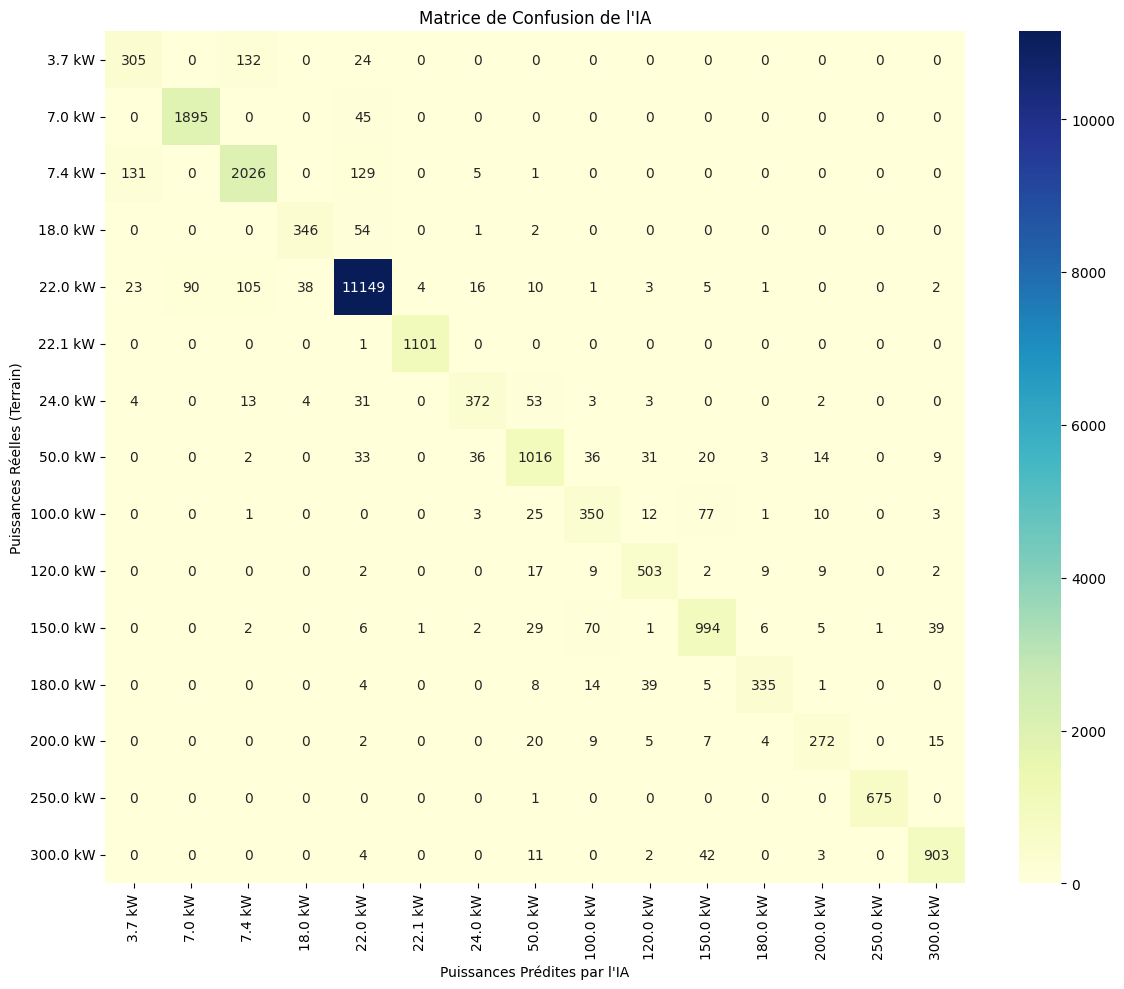


[SUCCÈS] La matrice ordonnée a été générée sans erreur !


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import joblib
import numpy as np

print("--- Évaluation graphique (Axes ordonnés - Version Sécurisée) ---")

# 1. Chargement du modèle qui a été sauvegardé avec succès par la cellule 2
model = joblib.load('best_classifier_besoin4.pkl')

# 2. Génération des prédictions sur le jeu de test
y_pred = model.predict(X_test_encoded)

# 3. On s'assure d'avoir les données au format texte
y_test_str = y_test.astype(str)
y_pred_str = y_pred.astype(str)

# 4. On extrait les puissances les plus fréquentes et on les trie NUMÉRIQUEMENT
top_classes_num = sorted(y_test.astype(float).value_counts().head(15).index.tolist())
top_classes_str = [str(c) for c in top_classes_num]

# 5. Calcul de la matrice de confusion
cm = confusion_matrix(y_test_str, y_pred_str, labels=top_classes_str)

# 6. Affichage graphique
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=[f"{float(c):.1f} kW" for c in top_classes_str],
            yticklabels=[f"{float(c):.1f} kW" for c in top_classes_str])

plt.title('Matrice de Confusion de l\'IA')
plt.xlabel('Puissances Prédites par l\'IA')
plt.ylabel('Puissances Réelles (Terrain)')
plt.tight_layout()

# Sauvegarde de la nouvelle image propre
plt.savefig('matrice_confusion_besoin4.png', dpi=300)
plt.show()

print("\n[SUCCÈS] La matrice ordonnée a été générée sans erreur !")

In [8]:
%%writefile prediction_puissance.py
import sys
import pandas as pd
import joblib
import numpy as np

def main():
    print("🔌   PROJET IRVE - SYSTÈME DE PRÉDICTION DE PUISSANCE     ")

    # 1. Chargement des fichiers de sauvegarde (.pkl)
    try:
        preprocesseur = joblib.load('preprocessor_besoin4.pkl')
        model = joblib.load('best_classifier_besoin4.pkl')
        print("[INFO] Modèle d'IA et préprocesseur chargés avec succès !\n")
    except FileNotFoundError:
        print("Erreur : Les fichiers '.pkl' sont introuvables dans ce dossier.")
        print("Veuillez vérifier que vous avez bien exécuté les cellules précédentes.")
        return

    # 2. Formulaire interactif pour le client
    print("--- Saisie des caractéristiques de la nouvelle station ---")

    nom_operateur = input("Nom de l'opérateur (ex: Freshmile, TotalEnergies, IECharge) : ")
    nom_enseigne = input("Nom de l'enseigne (ex: E.Leclerc, METRO, Autre) : ")
    implantation_station = input("Implantation (ex: Parking privé ouvert au public, Station-service) : ")
    accessibilite_pmr = input("Accessibilité PMR (accessible / non accessible) : ")
    condition_acces = input("Condition d'accès (ex: Accès libre, Réservé aux clients) : ")
    gratuit = input("Est-ce gratuit ? (true / false) : ")

    print("\n--- Types de prises installées sur la borne ---")
    prise_type_ef = input("Présence Prise Type EF / Domestique ? (true / false) : ")
    prise_type_2 = input("Présence Prise Type 2 ? (true / false) : ")
    prise_type_combo_ccs = input("Présence Prise Type Combo CCS ? (true / false) : ")
    prise_type_chademo = input("Présence Prise Type CHAdeMO ? (true / false) : ")
    prise_type_autre = input("Présence Autre type de prise ? (true / false) : ")

    print("\n--- Coordonnées Géographiques & Capacité ---")
    try:
        consolidated_longitude = float(input("Longitude de la borne (ex: 2.3522) : "))
        consolidated_latitude = float(input("Latitude de la borne (ex: 48.8566) : "))
        nbre_pdc = int(input("Nombre total de points de charge sur la station (ex: 4) : "))
    except ValueError:
        print("\n Erreur : La longitude, la latitude et le nombre de bornes doivent être des nombres numériques !")
        return

    # 3. Encapsulation des réponses dans un DataFrame au format strict de l'entraînement
    nouvelle_borne = pd.DataFrame([{
        'nom_operateur': nom_operateur,
        'nom_enseigne': nom_enseigne,
        'implantation_station': implantation_station,
        'accessibilite_pmr': accessibilite_pmr,
        'condition_acces': condition_acces,
        'gratuit': gratuit,
        'prise_type_ef': prise_type_ef,
        'prise_type_2': prise_type_2,
        'prise_type_combo_ccs': prise_type_combo_ccs,
        'prise_type_chademo': prise_type_chademo,
        'prise_type_autre': prise_type_autre,
        'consolidated_longitude': consolidated_longitude,
        'consolidated_latitude': consolidated_latitude,
        'nbre_pdc': nbre_pdc
    }])

    # 4. Encodage automatique des textes saisis via le préprocesseur enregistré
    try:
        borne_encodee = preprocesseur.transform(nouvelle_borne)
    except Exception as e:
        print(f"\n Erreur lors du traitement des données textuelles : {e}")
        return

    # 5. Prédiction finale
    puissance_predite = model.predict(borne_encodee)[0]

    print("🔮 RÉSULTAT DE L'INTELLIGENCE ARTIFICIELLE :")
    print(f"La puissance nominale estimée pour cette configuration est de : {float(puissance_predite):.1f} kW")

if __name__ == "__main__":
    main()

Writing prediction_puissance.py


In [9]:
!python prediction_puissance.py

🔌   PROJET IRVE - SYSTÈME DE PRÉDICTION DE PUISSANCE     
[INFO] Modèle d'IA et préprocesseur chargés avec succès !

--- Saisie des caractéristiques de la nouvelle station ---
Nom de l'opérateur (ex: Freshmile, TotalEnergies, IECharge) : TotalEnergies
Nom de l'enseigne (ex: E.Leclerc, METRO, Autre) : METRO
Implantation (ex: Parking privé ouvert au public, Station-service) : Parking privé ouvert au public
Accessibilité PMR (accessible / non accessible) : accessible
Condition d'accès (ex: Accès libre, Réservé aux clients) : Réservé aux clients 
Est-ce gratuit ? (true / false) : true

--- Types de prises installées sur la borne ---
Présence Prise Type EF / Domestique ? (true / false) : true 
Présence Prise Type 2 ? (true / false) : false
Présence Prise Type Combo CCS ? (true / false) : false
Présence Prise Type CHAdeMO ? (true / false) : true
Présence Autre type de prise ? (true / false) : false

--- Coordonnées Géographiques & Capacité ---
Longitude de la borne (ex: 2.3522) : 2.3522
Lati

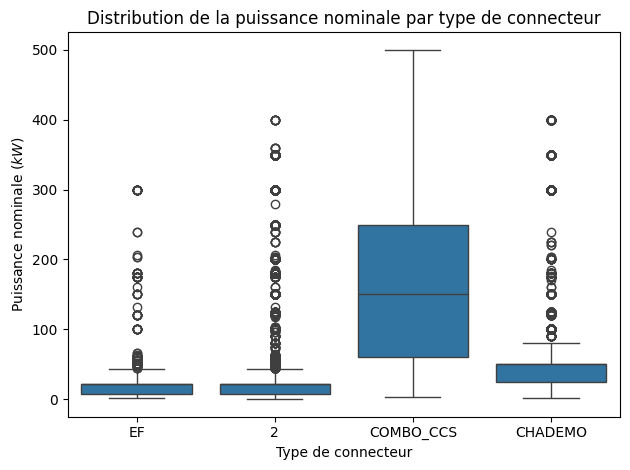

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Liste des colonnes de prises du schéma officiel
colonnes_prises = ['prise_type_ef', 'prise_type_2', 'prise_type_combo_ccs', 'prise_type_chademo']

# 2. On "pivote" le DataFrame pour créer une colonne 'type_connecteur' propre
df_long = df.melt(
    id_vars=['puissance_nominale'], # Variable numérique à conserver
    value_vars=colonnes_prises,     # Colonnes à regrouper
    var_name='type_connecteur',     # Nom de la nouvelle colonne des catégories
    value_name='disponible'         # True ou False
)

# 3. On ne garde que les lignes où la prise est effectivement présente (True)
df_long = df_long[df_long['disponible'] == True]

# Optionnel : Rendre les noms des axes plus propres (ex: 'prise_type_2' -> 'TYPE_2')
df_long['type_connecteur'] = df_long['type_connecteur'].str.replace('prise_type_', '').str.upper()

# 4. Tracé du Boxplot mis à jour
sns.boxplot(data=df_long, x='type_connecteur', y='puissance_nominale')
plt.title('Distribution de la puissance nominale par type de connecteur')
plt.xlabel('Type de connecteur')
plt.ylabel('Puissance nominale ($kW$)')
plt.tight_layout()
plt.show()